In [ ]:
#EX1

=== OC-SVM (linear kernel) ===
Balanced Accuracy: 0.9833333333333334
ROC AUC: 1.0


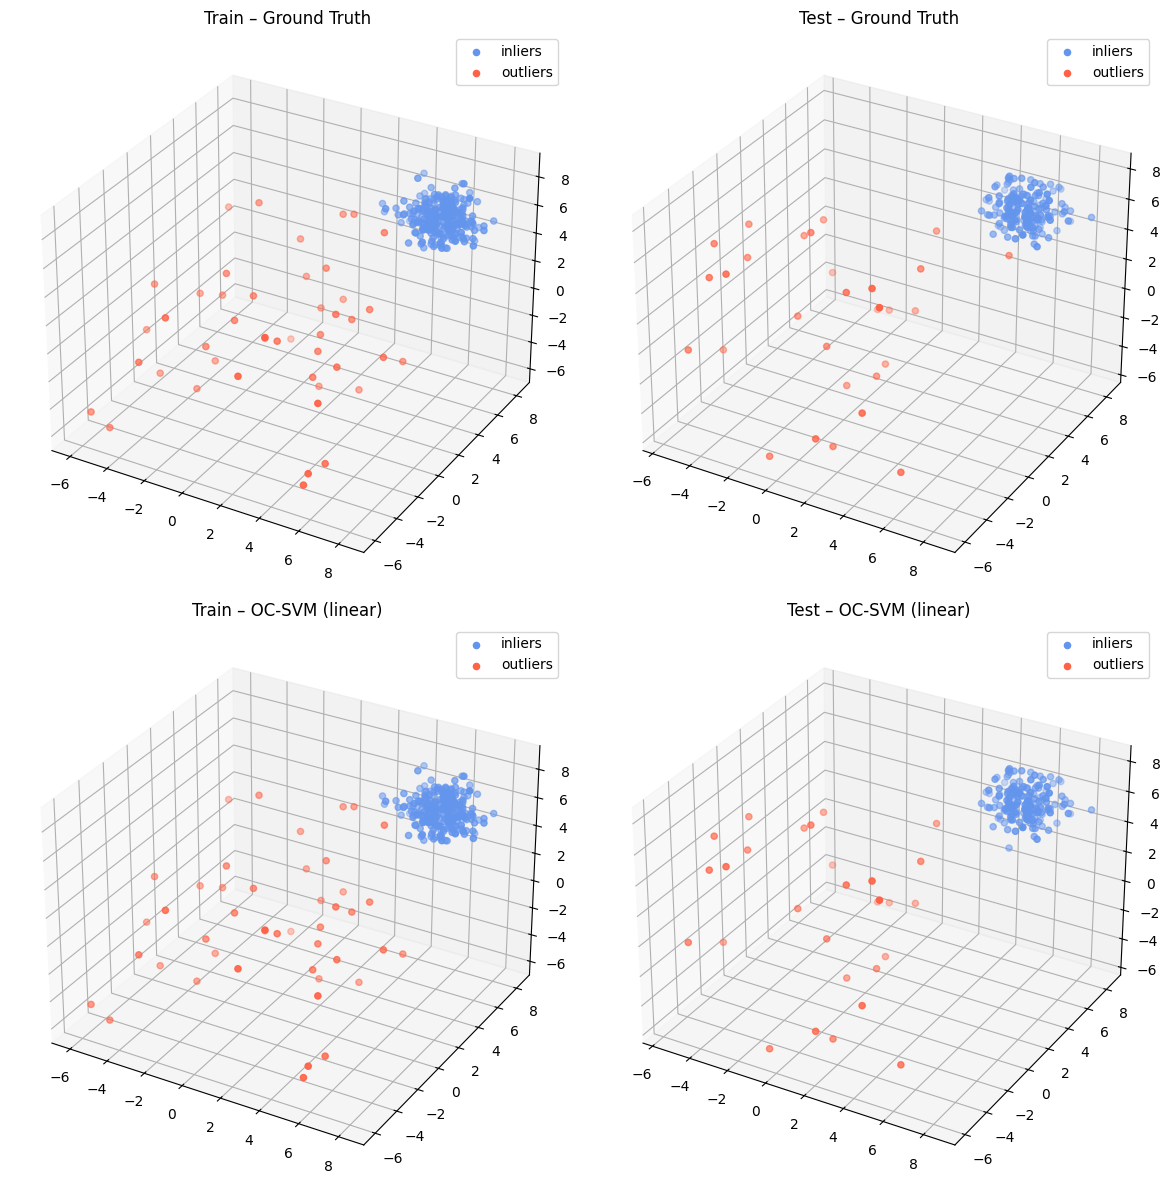

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from pyod.utils.data import generate_data
from pyod.models.ocsvm import OCSVM
from pyod.models.deep_svdd import DeepSVDD
from sklearn.metrics import balanced_accuracy_score, roc_auc_score

X_train, X_test, y_train, y_test = generate_data(
    n_train=300,
    n_test=200,
    n_features=3,
    contamination=0.15,
    random_state=42
)

ocsvm_lin = OCSVM(kernel="linear", contamination=0.15)
ocsvm_lin.fit(X_train)
train_pred_lin = ocsvm_lin.labels_
test_pred_lin = ocsvm_lin.predict(X_test)
test_scores_lin = ocsvm_lin.decision_function(X_test)
ba_lin = balanced_accuracy_score(y_test, test_pred_lin)
auc_lin = roc_auc_score(y_test, test_scores_lin)

print("=== OC-SVM (linear kernel) ===")
print("Balanced Accuracy:", ba_lin)
print("ROC AUC:", auc_lin)

def draw_cloud(ax, data, labels, title):
    """Render inliers/outliers in different colors in 3D."""
    ax.scatter(
        data[labels == 0, 0],
        data[labels == 0, 1],
        data[labels == 0, 2],
        c="cornflowerblue",
        label="inliers"
    )
    ax.scatter(
        data[labels == 1, 0],
        data[labels == 1, 1],
        data[labels == 1, 2],
        c="tomato",
        label="outliers"
    )
    ax.set_title(title)
    ax.legend()

fig = plt.figure(figsize=(12, 12))

ax1 = fig.add_subplot(221, projection="3d")
draw_cloud(ax1, X_train, y_train, "Train – Ground Truth")

ax2 = fig.add_subplot(222, projection="3d")
draw_cloud(ax2, X_test, y_test, "Test – Ground Truth")

ax3 = fig.add_subplot(223, projection="3d")
draw_cloud(ax3, X_train, train_pred_lin, "Train – OC-SVM (linear)")

ax4 = fig.add_subplot(224, projection="3d")
draw_cloud(ax4, X_test, test_pred_lin, "Test – OC-SVM (linear)")

plt.tight_layout()
plt.show()



=== OC-SVM (RBF kernel) ===
Balanced Accuracy: 0.9803921568627452
ROC AUC: 0.9998039215686275
Epoch 1/30, Loss: 11.969587743282318
Epoch 2/30, Loss: 11.985810995101929
Epoch 3/30, Loss: 10.918307602405548
Epoch 4/30, Loss: 11.204930663108826
Epoch 5/30, Loss: 11.232095956802368
Epoch 6/30, Loss: 10.986783266067505
Epoch 7/30, Loss: 11.583704352378845
Epoch 8/30, Loss: 11.450094997882843
Epoch 9/30, Loss: 11.465867221355438
Epoch 10/30, Loss: 10.869184404611588
Epoch 11/30, Loss: 12.06767064332962
Epoch 12/30, Loss: 11.819683492183685
Epoch 13/30, Loss: 11.345190346240997
Epoch 14/30, Loss: 11.261494874954224
Epoch 15/30, Loss: 11.403839349746704
Epoch 16/30, Loss: 11.033897578716278
Epoch 17/30, Loss: 11.048386365175247
Epoch 18/30, Loss: 11.415052056312561
Epoch 19/30, Loss: 10.75458100438118
Epoch 20/30, Loss: 11.049202799797058
Epoch 21/30, Loss: 10.840261191129684
Epoch 22/30, Loss: 11.073388576507568
Epoch 23/30, Loss: 11.277346312999725
Epoch 24/30, Loss: 11.53907060623169
Epoch

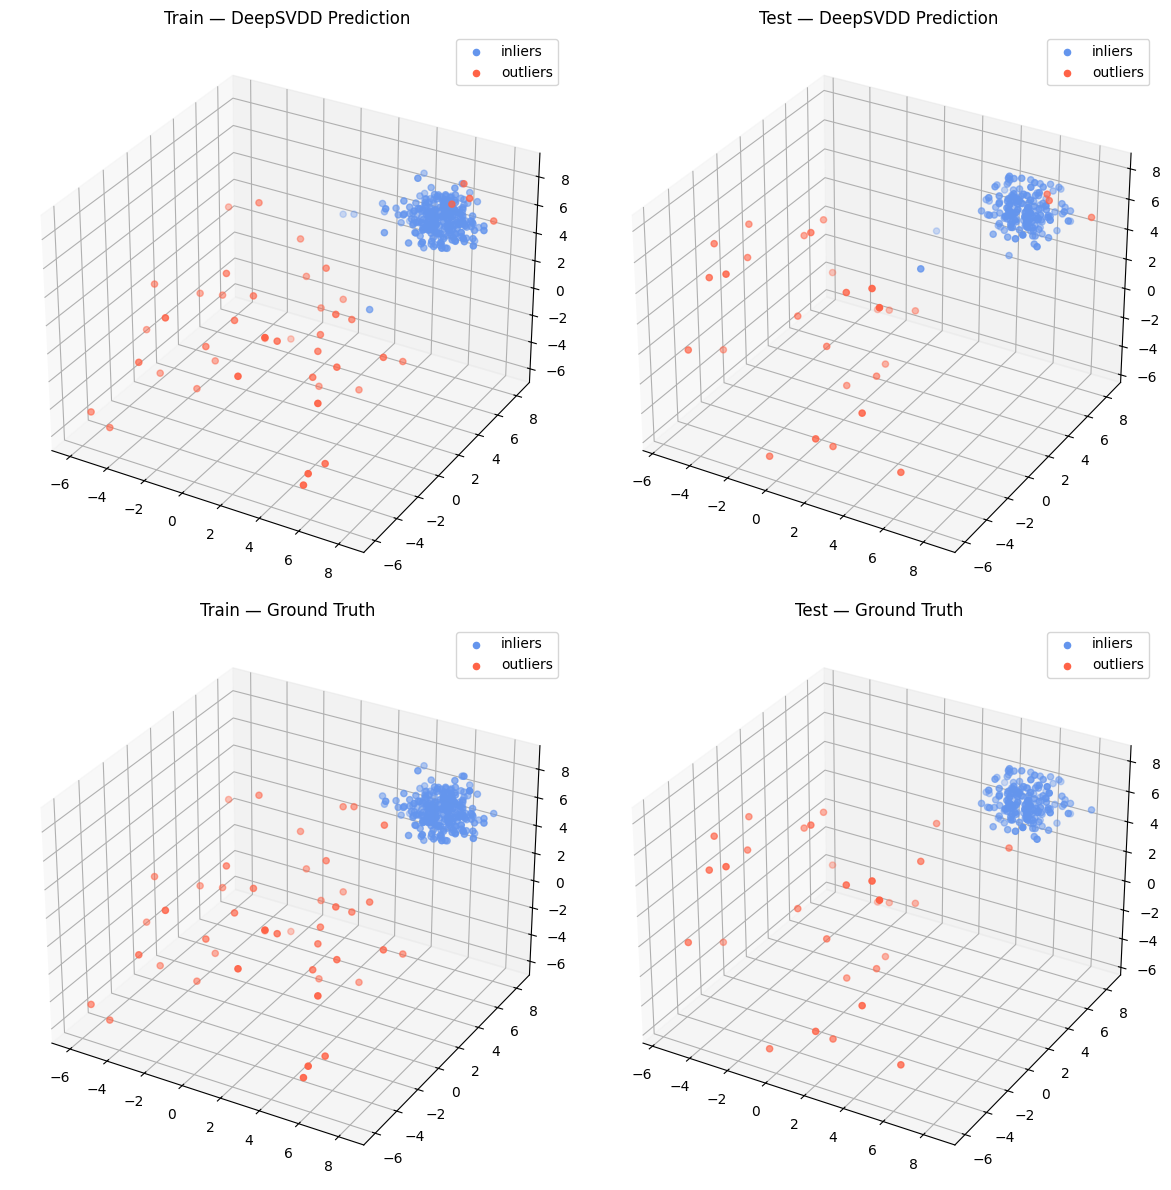

In [23]:
#OC-SVM with RBF Kernel — observe prediction differences
ocsvm_rbf = OCSVM(kernel="rbf", contamination=0.15)
ocsvm_rbf.fit(X_train)

rbf_test_pred = ocsvm_rbf.predict(X_test)
rbf_test_scores = ocsvm_rbf.decision_function(X_test)

ba_rbf = balanced_accuracy_score(y_test, rbf_test_pred)
auc_rbf = roc_auc_score(y_test, rbf_test_scores)

print("\n=== OC-SVM (RBF kernel) ===")
print("Balanced Accuracy:", ba_rbf)
print("ROC AUC:", auc_rbf)

svdd = DeepSVDD(
    contamination=0.15,
    epochs=30,
    batch_size=32,
    n_features=3
)
svdd.fit(X_train)

svdd_train_pred = svdd.labels_
svdd_test_pred = svdd.predict(X_test)
svdd_scores = svdd.decision_function(X_test)

ba_svdd = balanced_accuracy_score(y_test, svdd_test_pred)
auc_svdd = roc_auc_score(y_test, svdd_scores)

print("\n=== DeepSVDD Results ===")
print("Balanced Accuracy:", ba_svdd)
print("ROC AUC:", auc_svdd)

#Visualization for DeepSVDD (Predicted vs. Ground Truth)

fig2 = plt.figure(figsize=(12, 12))

axA = fig2.add_subplot(221, projection="3d")
draw_cloud(axA, X_train, svdd_train_pred, "Train — DeepSVDD Prediction")

axB = fig2.add_subplot(222, projection="3d")
draw_cloud(axB, X_test, svdd_test_pred, "Test — DeepSVDD Prediction")

axC = fig2.add_subplot(223, projection="3d")
draw_cloud(axC, X_train, y_train, "Train — Ground Truth")

axD = fig2.add_subplot(224, projection="3d")
draw_cloud(axD, X_test, y_test, "Test — Ground Truth")

plt.tight_layout()
plt.show()

In [ ]:
#EX2

In [24]:
from scipy.io import loadmat
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import OneClassSVM
from sklearn.pipeline import Pipeline
from sklearn.metrics import balanced_accuracy_score, make_scorer

raw = loadmat("cardio 1.mat")
X_all = raw["X"]
y_all = raw["y"].ravel()
X_tr, X_te, y_tr, y_te = train_test_split(
    X_all,
    y_all,
    test_size=0.4,
    random_state=10
)
y_tr_svm = np.where(y_tr == 1, -1, 1)
y_te_svm = np.where(y_te == 1, -1, 1)

train_cont_rate = (y_tr_svm == -1).sum() / len(y_tr_svm)

param_grid = {
    "svm__kernel": ["linear", "rbf"],
    "svm__gamma": ["scale", "auto"],
    "svm__nu": [0.3, 0.5, 0.8, train_cont_rate],
}
pipe = Pipeline([
    ("norm", StandardScaler()),
    ("svm", OneClassSVM())
])

grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring=make_scorer(balanced_accuracy_score),
    cv=5
)
grid.fit(X_tr, y_tr_svm)

best_pipeline = grid.best_estimator_
y_pred_test = best_pipeline.predict(X_te)

ba_test = balanced_accuracy_score(y_te_svm, y_pred_test)

print("Balanced Accuracy on test set:", ba_test)
print("Best parameter combination:", grid.best_params_)


Balanced Accuracy on test set: 0.8524707000316756
Best parameter combination: {'svm__gamma': 'scale', 'svm__kernel': 'rbf', 'svm__nu': 0.3}


In [25]:
#EX3

In [26]:
from scipy.io import loadmat
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import OneClassSVM
from sklearn.metrics import balanced_accuracy_score, roc_auc_score
from pyod.models.deep_svdd import DeepSVDD
import numpy as np
import warnings

warnings.filterwarnings("ignore")

raw = loadmat("shuttle 1.mat")
X = raw["X"]
y = raw["y"].ravel()
y = (y != 1).astype(int)

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.5, stratify=y, random_state=42)

scaler = StandardScaler()
X_tr = scaler.fit_transform(X_tr)
X_te = scaler.transform(X_te)

cont = 0.07

oc = OneClassSVM(kernel="rbf", gamma="scale", nu=cont)
oc.fit(X_tr)

pred_oc = oc.predict(X_te)
pred_oc = (-1 * pred_oc + 1)
scores_oc = -oc.decision_function(X_te)

ba_oc = balanced_accuracy_score(y_te, pred_oc)
auc_oc = roc_auc_score(y_te, scores_oc)

print("OC-SVM Results")
print("Balanced Accuracy:", ba_oc)
print("ROC AUC:", auc_oc)

architectures = [[32, 16], [64, 32]]

for i, arch in enumerate(architectures, 1):
    model = DeepSVDD(contamination=cont, epochs=30, batch_size=64, hidden_neurons=arch, n_features=X_tr.shape[1])
    model.fit(X_tr)

    pred_svdd = model.predict(X_te)
    scores_svdd = model.decision_function(X_te)

    ba_svdd = balanced_accuracy_score(y_te, pred_svdd)
    auc_svdd = roc_auc_score(y_te, scores_svdd)

    print(f"\nDeepSVDD Architecture {i} {arch}")
    print("Balanced Accuracy:", ba_svdd)
    print("ROC AUC:", auc_svdd)


OC-SVM Results
Balanced Accuracy: 0.27420273348519364
ROC AUC: 0.14218375901085406
Epoch 1/30, Loss: 151.87135205417871
Epoch 2/30, Loss: 151.5828343629837
Epoch 3/30, Loss: 151.57445546239614
Epoch 4/30, Loss: 151.61029873788357
Epoch 5/30, Loss: 151.57488676160574
Epoch 6/30, Loss: 151.58725794404745
Epoch 7/30, Loss: 151.57441948354244
Epoch 8/30, Loss: 151.61773309111595
Epoch 9/30, Loss: 152.0895775705576
Epoch 10/30, Loss: 151.61835731565952
Epoch 11/30, Loss: 151.67701622098684
Epoch 12/30, Loss: 151.56372247636318
Epoch 13/30, Loss: 151.63361486047506
Epoch 14/30, Loss: 151.54798205196857
Epoch 15/30, Loss: 151.6265981271863
Epoch 16/30, Loss: 151.6005758717656
Epoch 17/30, Loss: 151.53258043527603
Epoch 18/30, Loss: 151.61188465356827
Epoch 19/30, Loss: 151.5760364457965
Epoch 20/30, Loss: 151.58516933768988
Epoch 21/30, Loss: 151.58757261186838
Epoch 22/30, Loss: 151.57832538336515
Epoch 23/30, Loss: 151.5731862038374
Epoch 24/30, Loss: 151.53745935857296
Epoch 25/30, Loss: 1